# EDA Synthèse — BTGenBot × Nav4Rails

**Auteur :** Benjamin Lepourtois  
**Objectif :** unification des EDA Anne / Mohamed / Mourad + ajouts critiques (token count, JSONL trainable).

**Posture méthodologique :** comprendre et décrire le dataset utilisé par BTGenBot pour produire leurs résultats. **Pas redessiner leur pipeline.** Le papier ne mentionne aucun filtrage, le repo officiel ne contient pas le script de fine-tuning : on garde donc les **594 exemples bruts** pour fidélité maximale.

Livrables semaine 1 :
1. Chiffres clés consolidés (CSV + table Markdown)
2. Analyse descriptive des 16 XML invalides (pas de filtrage, juste documentation)
3. Catégories descriptives du dataset
4. Token count par BT (Llama-3.1 + Qwen2.5) — diagnostic troncature 4096
5. Recovery patterns (réutilisation Anne §4)
6. Smoke test set : 10-20 BTs isolés pour test rapide manuel
7. Export JSONL trainable (594 exemples, format chat)
8. Prompt v1 (papier) embarqué dans JSONL

## Section 0 — Setup

Imports, chemins, chargement du dataset brut.

In [1]:
import json
import re
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import xml.etree.ElementTree as ET

pd.set_option('display.max_colwidth', 80)
pd.set_option('display.max_rows', 50)

In [2]:
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
DATASET_DIR = PROJECT_ROOT / 'dataset'
DATASET_RAW_PATH = DATASET_DIR / 'bt_dataset.json'
SPLITS_DIR = DATASET_DIR / 'splits'
SPLITS_DIR.mkdir(parents=True, exist_ok=True)

print(f'PROJECT_ROOT = {PROJECT_ROOT}')
print(f'DATASET_RAW_PATH exists = {DATASET_RAW_PATH.exists()}')

PROJECT_ROOT = /home/bnj/WSL_RECUP/BTGenBot_Nav4Rails
DATASET_RAW_PATH exists = True


In [3]:
with DATASET_RAW_PATH.open('r', encoding='utf-8') as f:
    raw_data = json.load(f)

df = pd.DataFrame(raw_data).reset_index(names='record_id')
print(f'Dataset chargé : {len(df)} exemples')
print(f'Colonnes : {list(df.columns)}')
df.head(2)

Dataset chargé : 594 exemples
Colonnes : ['record_id', 'instruction', 'input', 'output']


,record_id,instruction,input,output
0,0,"You will be provided a summary of a task performed by a behavior tree, and y...",The behavior tree orchestrates the navigation of a robot by periodically rep...,<!--\n This Behavior Tree replans the global path periodically at 1 Hz.\n--...
1,1,"You will be provided a summary of a task performed by a behavior tree, and y...",The behavior tree is designed to control a robot's navigation with continuou...,<!--\n This Behavior Tree replans the global path after every 1m.\n-->\n\n<...


## Section 1 — Chiffres clés consolidés

**Objectif :** produire un tableau unique de ~20 métriques descriptives, exporté en CSV et en Markdown pour réutilisation dans le rapport et la présentation.

**Note sur la validité XML :** on rapporte **deux critères** pour transparence avec les EDA précédentes :
- **Parse strict (Mohamed)** : `ET.fromstring` direct → 578 valides (16 invalides)
- **Wrap + strip (Anne)** : encapsule dans `<dummy_root>`, strip `<?xml version="1.0"?>` exact → 571 valides (23 invalides, plus stricte par effet de bord de son strip naïf)

Ces deux chiffres servent **uniquement à décrire le dataset**. Le dataset utilisé pour le fine-tuning reste les **594 bruts** (fidélité papier).

Métriques calculées :
- Volume : total, 2 niveaux de validité XML
- Longueurs input/output (mots, caractères) : médiane, moyenne, p95, max
- Structure XML (sur valides strict) : node count, max depth
- Vocabulaire : tags XML uniques, skills métier uniques, variables blackboard `{var}`

In [4]:
# Critère 1 — parse strict (Mohamed) : ET.fromstring direct sur output
def parse_strict(xml_text):
    try:
        return ET.fromstring(xml_text), None
    except ET.ParseError as e:
        return None, str(e)

df['xml_root_strict'] = df['output'].apply(lambda t: parse_strict(t)[0])
df['xml_valid_strict'] = df['xml_root_strict'].notna()

# Critère 2 — wrap dummy_root + strip déclaration XML standard (Anne, reproduction exacte)
XML_DECLARATION_STR = '<?xml version="1.0"?>'

def parse_anne(xml_text):
    cleaned = xml_text.replace(XML_DECLARATION_STR, '').strip()
    try:
        return ET.fromstring(f'<dummy_root>{cleaned}</dummy_root>')
    except ET.ParseError:
        return None

df['xml_root_anne'] = df['output'].apply(parse_anne)
df['xml_valid_anne'] = df['xml_root_anne'].notna()

print(f'Valides parse strict (Mohamed) : {df["xml_valid_strict"].sum()} / {len(df)}')
print(f'Valides wrap+strip (Anne)      : {df["xml_valid_anne"].sum()} / {len(df)}')
print()
print('Note : Anne plus stricte par effet de bord — son strip ne gère que')
print('       <?xml version="1.0"?> exact. Les variantes (encoding=...) restent')
print('       en place et cassent le wrap dummy_root (declaration not at start).')

Valides parse strict (Mohamed) : 578 / 594
Valides wrap+strip (Anne)      : 571 / 594

Note : Anne plus stricte par effet de bord — son strip ne gère que
       <?xml version="1.0"?> exact. Les variantes (encoding=...) restent
       en place et cassent le wrap dummy_root (declaration not at start).


In [5]:
# Longueurs caractères et mots
df['input_char_count']  = df['input'].astype(str).str.len()
df['output_char_count'] = df['output'].astype(str).str.len()
df['input_word_count']  = df['input'].astype(str).str.split().str.len()
df['output_word_count'] = df['output'].astype(str).str.split().str.len()

In [6]:
# Structure XML (sur valides strict) : node count + depth
META_TAGS = {'TreeNodesModel', 'input_port', 'output_port', 'inout_port'}

def count_nodes(elem):
    if elem is None:
        return np.nan
    return sum(1 for e in elem.iter() if e.tag not in META_TAGS)

def max_depth(elem, d=0):
    if elem is None:
        return np.nan
    children = [c for c in elem if c.tag not in META_TAGS]
    if not children:
        return d
    return max(max_depth(c, d + 1) for c in children)

df['bt_node_count'] = df['xml_root_strict'].apply(count_nodes)
df['bt_max_depth']  = df['xml_root_strict'].apply(max_depth)

In [7]:
# Vocabulaire : tags XML uniques + skills métier (hors nœuds BT.CPP standards)
BTCPP_STANDARD = {
    'root', 'BehaviorTree', 'TreeNodesModel',
    'Sequence', 'SequenceStar', 'ReactiveSequence', 'PipelineSequence', 'NonBlockingSequence',
    'Fallback', 'FallbackStar', 'ReactiveFallback',
    'Parallel', 'ParallelAll',
    'Action', 'Condition', 'SubTree', 'Decorator',
    'Inverter', 'ForceSuccess', 'ForceFailure', 'KeepRunningUntilFailure',
    'RetryUntilSuccessful', 'Retry', 'RecoveryNode', 'RoundRobin',
    'Repeat', 'RateController', 'SpeedController', 'Timeout',
    'input_port', 'output_port', 'inout_port',
}

all_tags = Counter()
all_skills = Counter()  # noms sémantiques (attribut ID si Action/Condition, sinon tag)
blackboard_vars = set()
BB_RE = re.compile(r'\{[A-Za-z_][A-Za-z0-9_./:-]*\}')

for root in df.loc[df['xml_valid_strict'], 'xml_root_strict']:
    for elem in root.iter():
        all_tags[elem.tag] += 1
        if elem.tag in {'Action', 'Condition', 'SubTree'} and elem.get('ID'):
            all_skills[elem.get('ID')] += 1
        elif elem.tag not in BTCPP_STANDARD and elem.tag not in META_TAGS:
            all_skills[elem.tag] += 1
        for v in elem.attrib.values():
            blackboard_vars.update(BB_RE.findall(str(v)))

n_unique_tags = len(all_tags)
n_unique_skills = len(all_skills)
n_blackboard_vars = len(blackboard_vars)
print(f'Tags XML uniques        : {n_unique_tags}')
print(f'Skills métier uniques   : {n_unique_skills}')
print(f'Variables blackboard    : {n_blackboard_vars}')

Tags XML uniques        : 360
Skills métier uniques   : 1223
Variables blackboard    : 296


In [8]:
# Construction du tableau de chiffres clés (15-20 métriques)
valid_strict = df['xml_valid_strict'].sum()
valid_anne   = df['xml_valid_anne'].sum()
n_total = len(df)

df_valid_strict = df[df['xml_valid_strict']]

key_figures = pd.DataFrame([
    {'category': 'Volume',    'metric': "Nombre total d'exemples",                       'value': n_total},
    {'category': 'Volume',    'metric': 'XML valides (parse strict, Mohamed)',           'value': int(valid_strict)},
    {'category': 'Volume',    'metric': '% validité strict',                             'value': round(100 * valid_strict / n_total, 2)},
    {'category': 'Volume',    'metric': 'XML valides (wrap+strip, Anne)',                'value': int(valid_anne)},
    {'category': 'Volume',    'metric': '% validité Anne',                               'value': round(100 * valid_anne / n_total, 2)},
    {'category': 'Input',     'metric': 'Longueur input (mots) — médiane',               'value': int(df['input_word_count'].median())},
    {'category': 'Input',     'metric': 'Longueur input (mots) — moyenne',               'value': round(df['input_word_count'].mean(), 1)},
    {'category': 'Input',     'metric': 'Longueur input (mots) — p95',                   'value': int(df['input_word_count'].quantile(0.95))},
    {'category': 'Output',    'metric': 'Longueur XML (caractères) — médiane',           'value': int(df['output_char_count'].median())},
    {'category': 'Output',    'metric': 'Longueur XML (caractères) — moyenne',           'value': round(df['output_char_count'].mean(), 1)},
    {'category': 'Output',    'metric': 'Longueur XML (caractères) — p95',               'value': int(df['output_char_count'].quantile(0.95))},
    {'category': 'Output',    'metric': 'Longueur XML (caractères) — max',               'value': int(df['output_char_count'].max())},
    {'category': 'Structure', 'metric': 'Nb nœuds BT — médiane',                         'value': int(df_valid_strict['bt_node_count'].median())},
    {'category': 'Structure', 'metric': 'Nb nœuds BT — moyenne',                         'value': round(df_valid_strict['bt_node_count'].mean(), 1)},
    {'category': 'Structure', 'metric': 'Nb nœuds BT — max',                             'value': int(df_valid_strict['bt_node_count'].max())},
    {'category': 'Structure', 'metric': 'Profondeur BT — médiane',                       'value': int(df_valid_strict['bt_max_depth'].median())},
    {'category': 'Structure', 'metric': 'Profondeur BT — max',                           'value': int(df_valid_strict['bt_max_depth'].max())},
    {'category': 'Vocabulary','metric': 'Tags XML uniques',                              'value': n_unique_tags},
    {'category': 'Vocabulary','metric': 'Skills métier uniques (hors BT.CPP std)',       'value': n_unique_skills},
    {'category': 'Vocabulary','metric': 'Variables blackboard {var} uniques',            'value': n_blackboard_vars},
])

key_figures

,category,metric,value
0,Volume,Nombre total d'exemples,594.00
1,Volume,"XML valides (parse strict, Mohamed)",578.00
2,Volume,% validité strict,97.31
3,Volume,"XML valides (wrap+strip, Anne)",571.00
4,Volume,% validité Anne,96.13
5,Input,Longueur input (mots) — médiane,117.00
6,Input,Longueur input (mots) — moyenne,114.70
7,Input,Longueur input (mots) — p95,158.00
8,Output,Longueur XML (caractères) — médiane,1080.00
9,Output,Longueur XML (caractères) — moyenne,2651.60


In [9]:
# Export CSV
KEY_FIG_CSV = DATASET_DIR / 'key_figures.csv'
key_figures.to_csv(KEY_FIG_CSV, index=False)
print(f'CSV exporté : {KEY_FIG_CSV}')

# Export Markdown table (copiable directement dans rapport / TEX)
def df_to_markdown(df_in):
    cols = df_in.columns.tolist()
    lines = ['| ' + ' | '.join(cols) + ' |',
             '|' + '|'.join(['---'] * len(cols)) + '|']
    for _, row in df_in.iterrows():
        lines.append('| ' + ' | '.join(str(row[c]) for c in cols) + ' |')
    return '\n'.join(lines)

KEY_FIG_MD = DATASET_DIR / 'key_figures.md'
md = '# Chiffres clés dataset BTGenBot\n\n' + df_to_markdown(key_figures) + '\n'
KEY_FIG_MD.write_text(md, encoding='utf-8')
print(f'Markdown exporté : {KEY_FIG_MD}')

CSV exporté : /home/bnj/WSL_RECUP/BTGenBot_Nav4Rails/dataset/key_figures.csv
Markdown exporté : /home/bnj/WSL_RECUP/BTGenBot_Nav4Rails/dataset/key_figures.md


## Section 2 — Analyse descriptive des XML invalides

**Objectif (recadré) :** comprendre la nature des 16 XML non parsables — **pas filtrer le dataset**.

**Décision dataset final :** on garde les **594 exemples bruts** pour fidélité au papier BTGenBot. Le papier ne mentionne aucun filtrage, le repo officiel ne contient pas le script de fine-tuning. L'hypothèse par défaut est qu'ils ont utilisé le dataset brut (SFTTrainer apprend du texte, ne valide pas le XML).

Les 16 invalides (2.7%) sont mentionnés dans le rapport comme **caractéristique du dataset**, pas comme bruit à enlever.

Étapes :
- 2.1 Lister les 16 invalides avec leur erreur `ET.ParseError`
- 2.2 Catégoriser les types d'erreur
- 2.3 Inspecter 1-2 exemples par type

In [10]:
# 2.1 — Récupérer les 16 invalides (parse strict) + message d'erreur
def parse_error_msg(xml_text):
    try:
        ET.fromstring(xml_text)
        return None
    except ET.ParseError as e:
        return str(e)

df['parse_error'] = df['output'].apply(parse_error_msg)
df_invalid = df[df['parse_error'].notna()].copy()

print(f'Invalides parse strict : {len(df_invalid)}')
df_invalid[['record_id', 'parse_error']].reset_index(drop=True)

Invalides parse strict : 16


,record_id,parse_error
0,5,"not well-formed (invalid token): line 2, column 10"
1,6,"not well-formed (invalid token): line 2, column 10"
2,47,"not well-formed (invalid token): line 2, column 10"
3,89,"not well-formed (invalid token): line 2, column 10"
4,118,"mismatched tag: line 73, column 6"
5,211,"not well-formed (invalid token): line 2, column 10"
6,212,"not well-formed (invalid token): line 2, column 12"
7,261,"not well-formed (invalid token): line 2, column 10"
8,273,"mismatched tag: line 72, column 2"
9,291,"not well-formed (invalid token): line 6, column 56"


In [11]:
# 2.2 — Catégoriser les types d'erreur (heuristique sur le message)
def categorize_error(msg):
    m = msg.lower()
    if 'junk after document element' in m:
        return 'multi-root (XML avec plusieurs racines)'
    if 'not well-formed' in m and 'invalid token' in m:
        return 'token invalide (caractère illégal ou tag malformé)'
    if 'mismatched tag' in m:
        return 'tag non fermé / mal fermé'
    if 'declaration not at start' in m or 'xml or text declaration' in m:
        return 'déclaration XML mal placée'
    if 'no element found' in m:
        return 'document vide ou tronqué'
    if 'unbound prefix' in m:
        return 'namespace non déclaré'
    return f'autre : {msg[:60]}'

df_invalid['error_type'] = df_invalid['parse_error'].apply(categorize_error)
error_summary = df_invalid['error_type'].value_counts().reset_index()
error_summary.columns = ['type_erreur', 'count']
error_summary

,type_erreur,count
0,token invalide (caractère illégal ou tag malformé),12
1,tag non fermé / mal fermé,4


In [12]:
# 2.3 — Inspecter 1 exemple par type d'erreur (300 premiers caractères de l'output)
for err_type in df_invalid['error_type'].unique():
    sample = df_invalid[df_invalid['error_type'] == err_type].iloc[0]
    print(f'\n===== {err_type} =====')
    print(f'record_id : {sample["record_id"]}')
    print(f'erreur    : {sample["parse_error"]}')
    print(f'output (300 premiers chars) :')
    print(sample['output'][:300])
    print('...')


===== token invalide (caractère illégal ou tag malformé) =====
record_id : 5
erreur    : not well-formed (invalid token): line 2, column 10
output (300 premiers chars) :
<root main_tree_to_execute="BehaviorTree">
    <!--------------------------------------->
    <BehaviorTree ID="BehaviorTree">
        <Root>
            <Fallback name="FB1">
                <Sequence name="S1">
                    <Fallback name="FB2">
                        <Sequence name="S7">

...

===== tag non fermé / mal fermé =====
record_id : 118
erreur    : mismatched tag: line 73, column 6
output (300 premiers chars) :
<!-- Evitement
<ReactiveSequence>
<Fallback>
    <Condition ID="NoObstacle"/>
    <Avoid/>
</Fallback>
<Move pos= positions['P2'] />
</ReactiveSequence>
-->

<!-- AX1 : Open/Close clamp
    AX2 : Move clamp forward/backwards
    AX3 : Moe clamp left/right
    AX4 :  Turn clamp
-->

<root main_tree_t
...


In [13]:
# 2.4 — Export descriptif des 16 invalides (référence rapport)
INVALID_CSV = DATASET_DIR / 'invalid_xml_examples.csv'
df_invalid[['record_id', 'error_type', 'parse_error']].to_csv(INVALID_CSV, index=False)
print(f'CSV invalides exporté : {INVALID_CSV}')

# Génère section Markdown pour rapport
md = '## XML invalides dans BTGenBot dataset\n\n'
md += f'**Total :** {len(df_invalid)} / {len(df)} ({100*len(df_invalid)/len(df):.2f}%)\n\n'
md += '### Distribution par type\n\n| Type | Count |\n|---|---|\n'
for _, r in error_summary.iterrows():
    md += f'| {r["type_erreur"]} | {r["count"]} |\n'
md += f'\n**Décision :** dataset conservé tel quel (594 exemples) pour fidélité au papier BTGenBot, qui n\'applique aucun filtrage documenté.\n'

INVALID_MD = DATASET_DIR / 'invalid_xml_report.md'
INVALID_MD.write_text(md, encoding='utf-8')
print(f'Markdown rapport exporté : {INVALID_MD}')

CSV invalides exporté : /home/bnj/WSL_RECUP/BTGenBot_Nav4Rails/dataset/invalid_xml_examples.csv
Markdown rapport exporté : /home/bnj/WSL_RECUP/BTGenBot_Nav4Rails/dataset/invalid_xml_report.md


## Section 3 — Catégories descriptives

**Objectif :** classer les 594 BTs en 5 catégories pour décrire de quoi le dataset BTGenBot parle. Sert au rapport et à la présentation. **Pas utilisé pour split.**

**Méthode hybride :**
- Priorité : **tags XML** présents dans le BT (vérité terrain, sur les 578 valides)
- Fallback : **regex sur input texte** si XML invalide (16 cas restants)

**5 catégories canoniques :**
- `navigation` : Nav2, waypoints, planner, costmap, goal
- `manipulation` : arm, gripper, pick, place, joint
- `perception` : vision, aruco, detect, scan, lidar
- `exploration` : explore, frontier, coverage
- `other` : reste (assemblage, interaction, IA générique)

**Flag transverse :** `has_recovery_pattern` = booléen, présence de `Fallback`/`RecoveryNode` avec sous-séquence imbriquée (motif "essayer puis se rabattre").

In [14]:
# 3.1 — Définition des keywords par catégorie (XML skills + regex texte)
CATEGORY_KEYWORDS = {
    'navigation':    [r'\bnav\w*\b', r'\bwaypoint\b', r'\bgoal\b', r'\bpath\b', r'\bplanner\b',
                      r'\bcostmap\b', r'\bcontroller\b', r'\bmove\w*\b', r'\bspin\b', r'\bbacktrack\b'],
    'manipulation':  [r'\barm\b', r'\bgripper\b', r'\bpick\b', r'\bplace\b', r'\bgrasp\b',
                      r'\bjoint\b', r'\bmanipulat\w*\b', r'\bclamp\b'],
    'perception':    [r'\bvision\b', r'\baruco\b', r'\bdetect\w*\b', r'\bscan\b', r'\blidar\b',
                      r'\bcamera\b', r'\bperceiv\w*\b', r'\bobserv\w*\b'],
    'exploration':   [r'\bexplor\w*\b', r'\bfrontier\b', r'\bcoverage\b', r'\bscout\b',
                      r'\bsurvey\b', r'\bmap\w*\b'],
}

# Compilation regex (insensible casse)
CATEGORY_PATTERNS = {
    cat: [re.compile(p, re.IGNORECASE) for p in pats]
    for cat, pats in CATEGORY_KEYWORDS.items()
}

print('Catégories définies :', list(CATEGORY_KEYWORDS.keys()) + ['other'])

Catégories définies : ['navigation', 'manipulation', 'perception', 'exploration', 'other']


In [15]:
# 3.2 — Classification hybride : signal XML (skills) prioritaire, fallback regex texte
def extract_xml_signal(root):
    if root is None:
        return ''
    tokens = []
    for elem in root.iter():
        if elem.tag in {'Action', 'Condition', 'SubTree'} and elem.get('ID'):
            tokens.append(elem.get('ID'))
        elif elem.tag not in BTCPP_STANDARD and elem.tag not in META_TAGS:
            tokens.append(elem.tag)
    return ' '.join(tokens)

df['xml_signal'] = df['xml_root_strict'].apply(extract_xml_signal)

def classify_text(text):
    if not text:
        return 'other', 0
    scores = {cat: sum(len(p.findall(text)) for p in pats)
              for cat, pats in CATEGORY_PATTERNS.items()}
    best = max(scores, key=scores.get)
    return (best, scores[best]) if scores[best] > 0 else ('other', 0)

def categorize_hybrid(row):
    # Priorité : XML signal si valide
    if row['xml_valid_strict']:
        cat, score = classify_text(row['xml_signal'])
        if cat != 'other':
            return cat
    # Fallback : input texte
    cat, _ = classify_text(str(row['input']))
    return cat

df['category'] = df.apply(categorize_hybrid, axis=1)
distrib = df['category'].value_counts()
print('Distribution catégories :')
print(distrib.to_string())
print(f'\nTotal : {distrib.sum()} / {len(df)}')

Distribution catégories :
category
navigation      434
other           100
manipulation     43
perception       15
exploration       2

Total : 594 / 594


In [16]:
# 3.3 — Flag transverse has_recovery_pattern : Fallback/RecoveryNode avec Sequence imbriquée
RECOVERY_PARENTS = {'Fallback', 'FallbackStar', 'ReactiveFallback', 'RecoveryNode'}
SEQ_CHILDREN = {'Sequence', 'SequenceStar', 'ReactiveSequence', 'PipelineSequence', 'NonBlockingSequence'}

def has_recovery_pattern(root):
    if root is None:
        return False
    for elem in root.iter():
        if elem.tag in RECOVERY_PARENTS:
            for child in elem:
                if child.tag in SEQ_CHILDREN:
                    return True
    return False

df['has_recovery_pattern'] = df['xml_root_strict'].apply(has_recovery_pattern)
n_recovery = df['has_recovery_pattern'].sum()
print(f'BTs avec recovery pattern : {n_recovery} / {len(df)} ({100*n_recovery/len(df):.1f}%)')
print('\nCroisement catégorie × recovery :')
print(pd.crosstab(df['category'], df['has_recovery_pattern'], margins=True))

BTs avec recovery pattern : 224 / 594 (37.7%)

Croisement catégorie × recovery :


has_recovery_pattern  False  True  All
category                              
exploration               1     1    2
manipulation             32    11   43
navigation              242   192  434
other                    85    15  100
perception               10     5   15
All                     370   224  594


In [17]:
# 3.4 — Export catégories + flag pour rapport
CAT_CSV = DATASET_DIR / 'categories.csv'
df[['record_id', 'category', 'has_recovery_pattern']].to_csv(CAT_CSV, index=False)
print(f'CSV catégories exporté : {CAT_CSV}')

# Markdown rapport
md = '## Catégories descriptives du dataset BTGenBot\n\n'
md += '### Distribution principale\n\n| Catégorie | Count | % |\n|---|---|---|\n'
for cat, cnt in distrib.items():
    md += f'| {cat} | {cnt} | {100*cnt/len(df):.1f}% |\n'
md += f'\n**Total :** {len(df)}\n\n'
md += '### Flag transverse `has_recovery_pattern`\n\n'
md += f'**BTs avec pattern recovery :** {n_recovery} / {len(df)} ({100*n_recovery/len(df):.1f}%)\n\n'
md += '### Croisement catégorie × recovery\n\n'
ct = pd.crosstab(df['category'], df['has_recovery_pattern'])
md += '| Catégorie | sans recovery | avec recovery |\n|---|---|---|\n'
for cat in ct.index:
    md += f'| {cat} | {ct.loc[cat, False]} | {ct.loc[cat, True]} |\n'
md += '\n**Méthode :** classification hybride — signal XML (skills présents) prioritaire, fallback regex texte si XML invalide.\n\n'
md += '### Implication pour le transfert SNCF\n\n'
md += 'SNCF NAV4RAIL = **inspection ferroviaire** = navigation + perception.\n\n'
md += 'Dataset BTGenBot **bien aligné côté navigation** (73% des exemples), '
md += '**faible côté perception** (15 exemples, 2.5%) → mauvaise nouvelle pour le transfert direct '
md += "sur les skills perception du catalogue SNCF. Le modèle apprendra solidement les patterns Nav2 "
md += "mais aura peu de signal pour les actions de capture/analyse visuelle propres à l'inspection ferroviaire.\n"

CAT_MD = DATASET_DIR / 'categories_report.md'
CAT_MD.write_text(md, encoding='utf-8')
print(f'Markdown rapport exporté : {CAT_MD}')

CSV catégories exporté : /home/bnj/WSL_RECUP/BTGenBot_Nav4Rails/dataset/categories.csv
Markdown rapport exporté : /home/bnj/WSL_RECUP/BTGenBot_Nav4Rails/dataset/categories_report.md


### Graphes descriptifs

4 figures essentielles sauvegardées dans `dataset/figs/` (PNG) pour réutilisation dans le rapport et le TEX :
- **`longueurs.png`** : histogrammes input (mots) + output (chars + log) — reproduit Mohamed §2
- **`top_tags.png`** : Top 20 tags XML (barh) — reproduit Mohamed §4
- **`structure.png`** : histogrammes node count + max depth — reproduit Mohamed §6
- **`categories.png`** : distribution catégories + flag recovery (notre catégorisation hybride)

In [18]:
# 3.5 — Setup matplotlib + chemin figs/
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

FIGS_DIR = DATASET_DIR / 'figs'
FIGS_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 150, 'savefig.bbox': 'tight'})

COLOR_PRIMARY   = '#4C78A8'
COLOR_SECONDARY = '#72B7B2'
COLOR_ACCENT    = '#F58518'

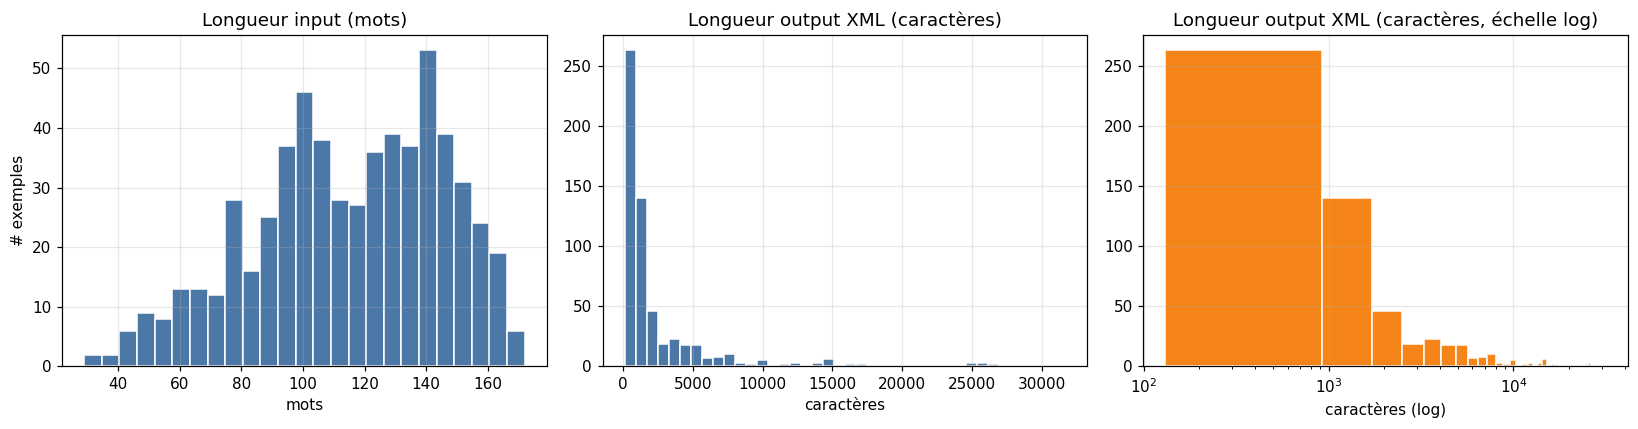

In [19]:
# Graphe 1 — Longueurs : input (mots), output (chars), output (chars log)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['input_word_count'].hist(ax=axes[0], bins=25, color=COLOR_PRIMARY, edgecolor='white')
axes[0].set_title('Longueur input (mots)')
axes[0].set_xlabel('mots'); axes[0].set_ylabel('# exemples')

df['output_char_count'].hist(ax=axes[1], bins=40, color=COLOR_PRIMARY, edgecolor='white')
axes[1].set_title('Longueur output XML (caractères)')
axes[1].set_xlabel('caractères')

df['output_char_count'].hist(ax=axes[2], bins=40, color=COLOR_ACCENT, edgecolor='white')
axes[2].set_xscale('log')
axes[2].set_title('Longueur output XML (caractères, échelle log)')
axes[2].set_xlabel('caractères (log)')

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGS_DIR / 'longueurs.png')
plt.show()

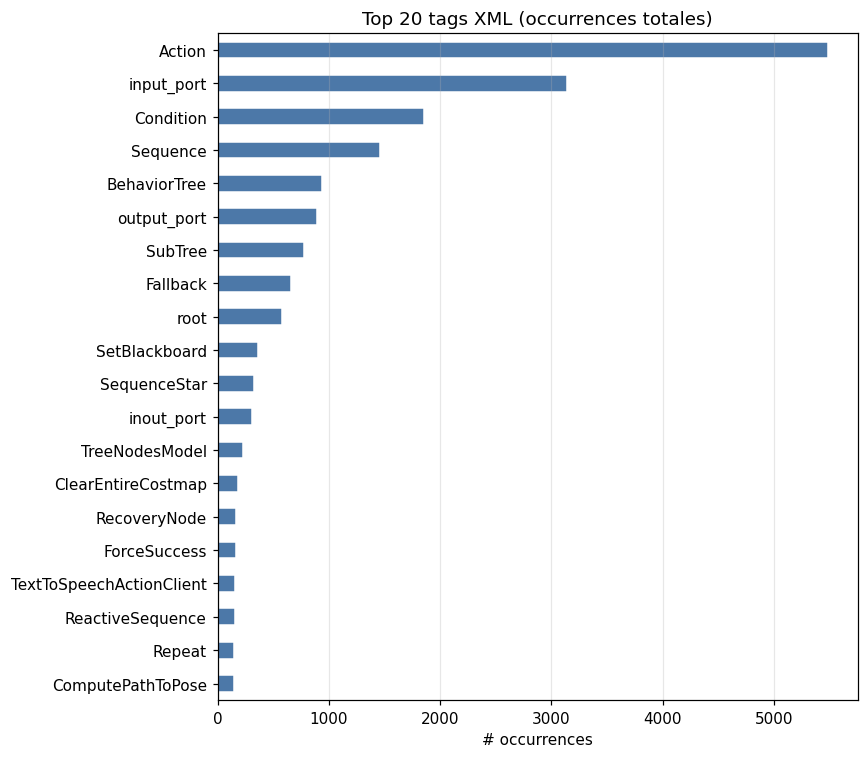

In [20]:
# Graphe 2 — Top 20 tags XML (barh)
top_tags = pd.Series(all_tags).sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(8, 7))
top_tags.plot(kind='barh', color=COLOR_PRIMARY, ax=ax, edgecolor='white')
ax.set_title('Top 20 tags XML (occurrences totales)')
ax.set_xlabel('# occurrences')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(FIGS_DIR / 'top_tags.png')
plt.show()

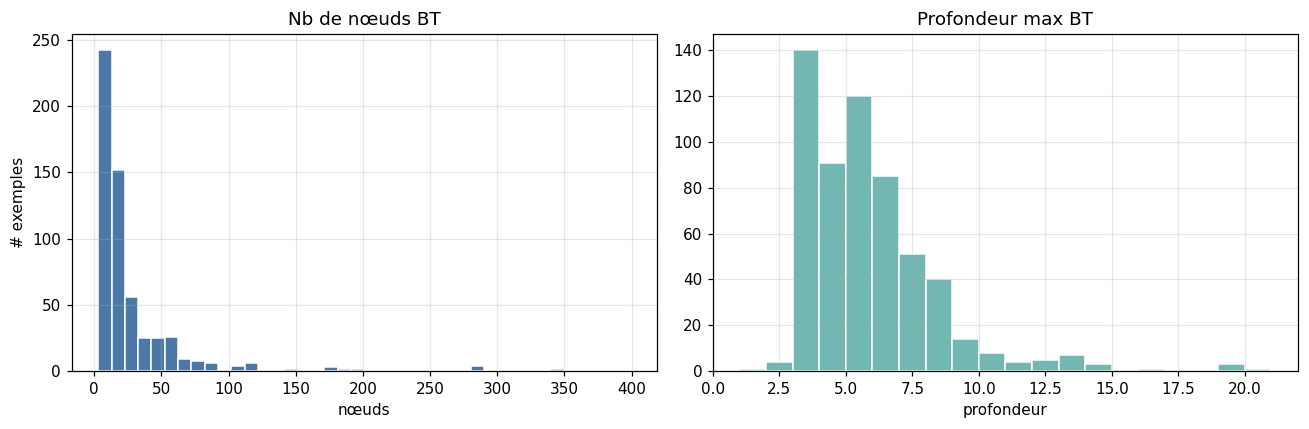

In [21]:
# Graphe 3 — Structure : node count + max depth (sur valides strict)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_valid_strict['bt_node_count'].dropna().astype(int).hist(
    ax=axes[0], bins=40, color=COLOR_PRIMARY, edgecolor='white')
axes[0].set_title('Nb de nœuds BT')
axes[0].set_xlabel('nœuds'); axes[0].set_ylabel('# exemples')

df_valid_strict['bt_max_depth'].dropna().astype(int).hist(
    ax=axes[1], bins=20, color=COLOR_SECONDARY, edgecolor='white')
axes[1].set_title('Profondeur max BT')
axes[1].set_xlabel('profondeur')

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGS_DIR / 'structure.png')
plt.show()

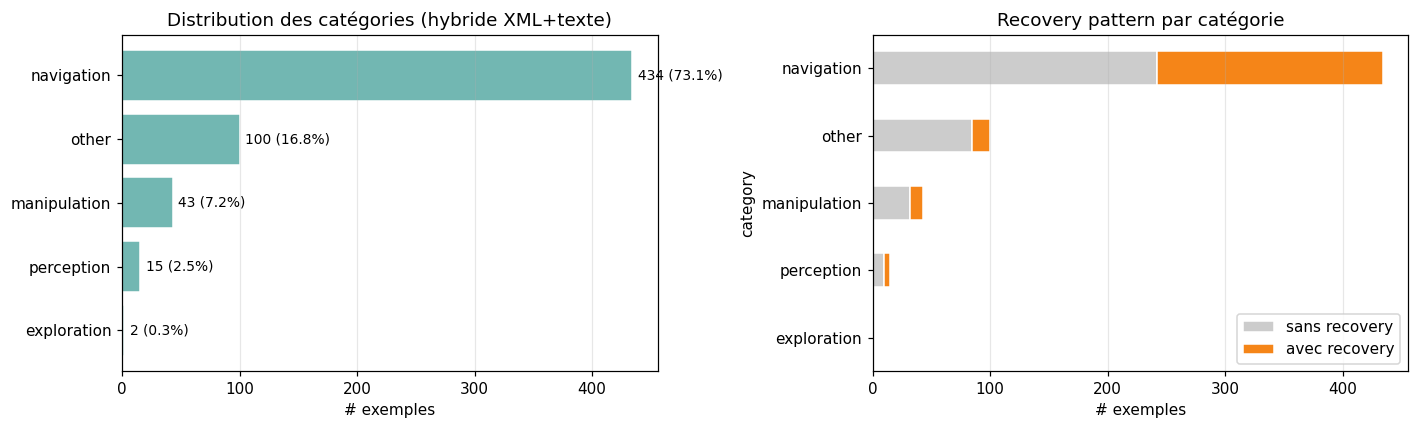


Figures sauvegardées dans : /home/bnj/WSL_RECUP/BTGenBot_Nav4Rails/dataset/figs
Fichiers : ['categories.png', 'longueurs.png', 'recovery_patterns_d2.png', 'recovery_patterns_d3.png', 'structure.png', 'tokens_comparison.png', 'tokens_distribution.png', 'tokens_distribution_llama.png', 'tokens_distribution_qwen.png', 'top_tags.png']


In [22]:
# Graphe 4 — Catégories : distribution + ventilation recovery
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribution catégories
distrib_sorted = distrib.sort_values()
axes[0].barh(distrib_sorted.index, distrib_sorted.values, color=COLOR_SECONDARY, edgecolor='white')
axes[0].set_title('Distribution des catégories (hybride XML+texte)')
axes[0].set_xlabel('# exemples')
for i, v in enumerate(distrib_sorted.values):
    axes[0].text(v + 5, i, f'{v} ({100*v/len(df):.1f}%)', va='center', fontsize=9)
axes[0].grid(alpha=0.3, axis='x')

# Recovery par catégorie (stacked)
ct = pd.crosstab(df['category'], df['has_recovery_pattern']).reindex(distrib_sorted.index)
ct.plot(kind='barh', stacked=True, ax=axes[1],
        color=['#cccccc', COLOR_ACCENT], edgecolor='white')
axes[1].set_title('Recovery pattern par catégorie')
axes[1].set_xlabel('# exemples')
axes[1].legend(['sans recovery', 'avec recovery'], loc='lower right')
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(FIGS_DIR / 'categories.png')
plt.show()

print(f'\nFigures sauvegardées dans : {FIGS_DIR}')
print('Fichiers :', sorted(f.name for f in FIGS_DIR.glob('*.png')))

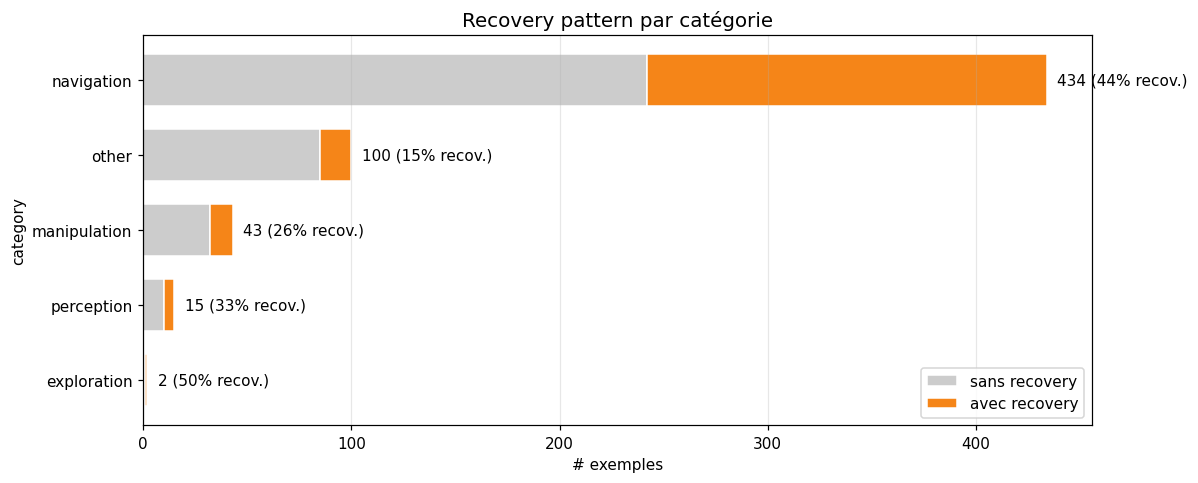

Saved categories_recovery.png


In [23]:
# 3.5bis — Catégories : recovery par catégorie en grand format (slide-friendly)
fig, ax = plt.subplots(figsize=(11, 4.5))
distrib_sorted = df['category'].value_counts().sort_values()
ct_sorted = pd.crosstab(df['category'], df['has_recovery_pattern']).reindex(distrib_sorted.index)

ct_sorted.plot(kind='barh', stacked=True, ax=ax,
               color=['#cccccc', COLOR_ACCENT], edgecolor='white', width=0.7)
ax.set_title('Recovery pattern par catégorie', fontsize=13)
ax.set_xlabel('# exemples')
ax.legend(['sans recovery', 'avec recovery'], loc='lower right')
ax.grid(alpha=0.3, axis='x')

# Annotation totaux et % recovery par catégorie
for i, cat in enumerate(ct_sorted.index):
    total = ct_sorted.loc[cat].sum()
    with_r = ct_sorted.loc[cat, True]
    pct = 100 * with_r / total if total else 0
    ax.text(total + 5, i, f'{total} ({pct:.0f}% recov.)', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(FIGS_DIR / 'categories_recovery.png')
plt.show()
print('Saved categories_recovery.png')


## Section 4 — Token count Llama-3.1 + Qwen2.5

**Objectif :** mesurer combien de tokens chaque exemple consomme dans les tokenizers que nous utiliserons pour le SFT. Diagnostic clé : **% d'exemples tronqués** à différents seuils `max_seq_length` (2048 / 4096 / 8192).

**Pourquoi pertinent vs papier :** BTGenBot fixe `max_seq_length=4096` sans documenter la distribution. Avec un dataset où certains XML font 31k caractères et 399 nœuds, il y a des chances qu'une fraction non-triviale soit tronquée silencieusement, ce qui injecte du bruit dans la loss SFT. Notre rapport documentera ce taux.

**Tokenizers :**
- `meta-llama/Llama-3.1-8B` (vocab 128k) — fallback `NousResearch/Meta-Llama-3.1-8B` si gating HF
- `Qwen/Qwen2.5-7B` (vocab 151k) — pas de gating. **Identique** à Qwen2.5-Coder, donc 1 mesure couvre les 2 modèles

**Métriques par exemple :**
- `tokens_input` : tokens du champ `input` seul
- `tokens_output` : tokens du champ `output` seul
- `tokens_total_chat` : tokens du message complet avec `apply_chat_template` (system+user+assistant)

In [24]:
# 4.1 — Chargement des tokenizers (sans télécharger le modèle complet, juste tokenizer.json)
from transformers import AutoTokenizer
import warnings
warnings.filterwarnings('ignore')

LLAMA_CANDIDATES = ['meta-llama/Llama-3.1-8B-Instruct', 'NousResearch/Meta-Llama-3.1-8B-Instruct',
                    'unsloth/Meta-Llama-3.1-8B-Instruct']
QWEN_ID = 'Qwen/Qwen2.5-7B-Instruct'

def load_tokenizer_with_fallback(candidates):
    for c in candidates if isinstance(candidates, list) else [candidates]:
        try:
            tok = AutoTokenizer.from_pretrained(c, use_fast=True, trust_remote_code=False)
            print(f'  [ok] {c} — vocab_size={tok.vocab_size}')
            return tok, c
        except Exception as e:
            print(f'  [ko] {c} — {type(e).__name__}: {str(e)[:80]}')
    raise RuntimeError('Aucun tokenizer chargeable')

print('Chargement Llama-3.1 :')
tok_llama, llama_used = load_tokenizer_with_fallback(LLAMA_CANDIDATES)

print('\nChargement Qwen2.5 :')
tok_qwen, qwen_used = load_tokenizer_with_fallback(QWEN_ID)

[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Chargement Llama-3.1 :


  [ko] meta-llama/Llama-3.1-8B-Instruct — OSError: You are trying to access a gated repo.
Make sure to have access to it at https:/


  [ok] NousResearch/Meta-Llama-3.1-8B-Instruct — vocab_size=128000

Chargement Qwen2.5 :


  [ok] Qwen/Qwen2.5-7B-Instruct — vocab_size=151643


In [25]:
# 4.2 — Tokenisation : input seul, output seul, total chat-template (system+user+assistant)
SYSTEM_MSG = (
    'You will be provided a summary of a task performed by a behavior tree, '
    'and your objective is to express this behavior tree in XML format.'
)

def count_tokens(tok, text):
    return len(tok.encode(text, add_special_tokens=False))

def count_chat_total(tok, user_text, assistant_text):
    msgs = [
        {'role': 'system',    'content': SYSTEM_MSG},
        {'role': 'user',      'content': user_text},
        {'role': 'assistant', 'content': assistant_text},
    ]
    formatted = tok.apply_chat_template(msgs, tokenize=False, add_generation_prompt=False)
    return len(tok.encode(formatted, add_special_tokens=False))

for label, tok in [('llama', tok_llama), ('qwen', tok_qwen)]:
    df[f'tok_{label}_input']  = df['input'].astype(str).apply(lambda t: count_tokens(tok, t))
    df[f'tok_{label}_output'] = df['output'].astype(str).apply(lambda t: count_tokens(tok, t))
    df[f'tok_{label}_total']  = df.apply(
        lambda r: count_chat_total(tok, str(r['input']), str(r['output'])), axis=1)
    print(f'{label}: tokenisation OK')

df[['tok_llama_input','tok_llama_output','tok_llama_total',
    'tok_qwen_input','tok_qwen_output','tok_qwen_total']].describe().round(1)

llama: tokenisation OK


qwen: tokenisation OK


,tok_llama_input,tok_llama_output,tok_llama_total,tok_qwen_input,tok_qwen_output,tok_qwen_total
count,594.0,594.0,594.0,594.0,594.0,594.0
mean,140.9,601.6,790.4,141.2,615.2,799.3
std,38.9,1028.4,1046.4,38.9,1087.1,1104.7
min,36.0,37.0,125.0,36.0,37.0,120.0
25%,114.0,142.0,312.0,114.0,142.0,307.2
50%,145.0,242.0,439.0,145.0,252.5,436.5
75%,172.8,533.0,756.8,172.8,533.0,751.8
max,200.0,8283.0,8530.0,200.0,9651.0,9894.0


In [26]:
# 4.3 — Percentiles + % tronqué selon max_seq_length
THRESHOLDS = [2048, 4096, 8192]

rows = []
for label in ['llama', 'qwen']:
    s = df[f'tok_{label}_total']
    row = {
        'tokenizer': label,
        'mean':  round(s.mean(), 1),
        'p50':   int(s.median()),
        'p90':   int(s.quantile(0.90)),
        'p95':   int(s.quantile(0.95)),
        'p99':   int(s.quantile(0.99)),
        'max':   int(s.max()),
    }
    for t in THRESHOLDS:
        n_trunc = (s > t).sum()
        row[f'%>{t}'] = round(100 * n_trunc / len(s), 2)
    rows.append(row)

trunc_table = pd.DataFrame(rows)
print('Distribution tokens TOTAL (input + output + chat template) :')
trunc_table

Distribution tokens TOTAL (input + output + chat template) :


,tokenizer,mean,p50,p90,p95,p99,max,%>2048,%>4096,%>8192
0,llama,790.4,439,1595,2510,6508,8530,6.57,2.02,0.17
1,qwen,799.3,436,1599,2513,6667,9894,6.73,2.36,0.34


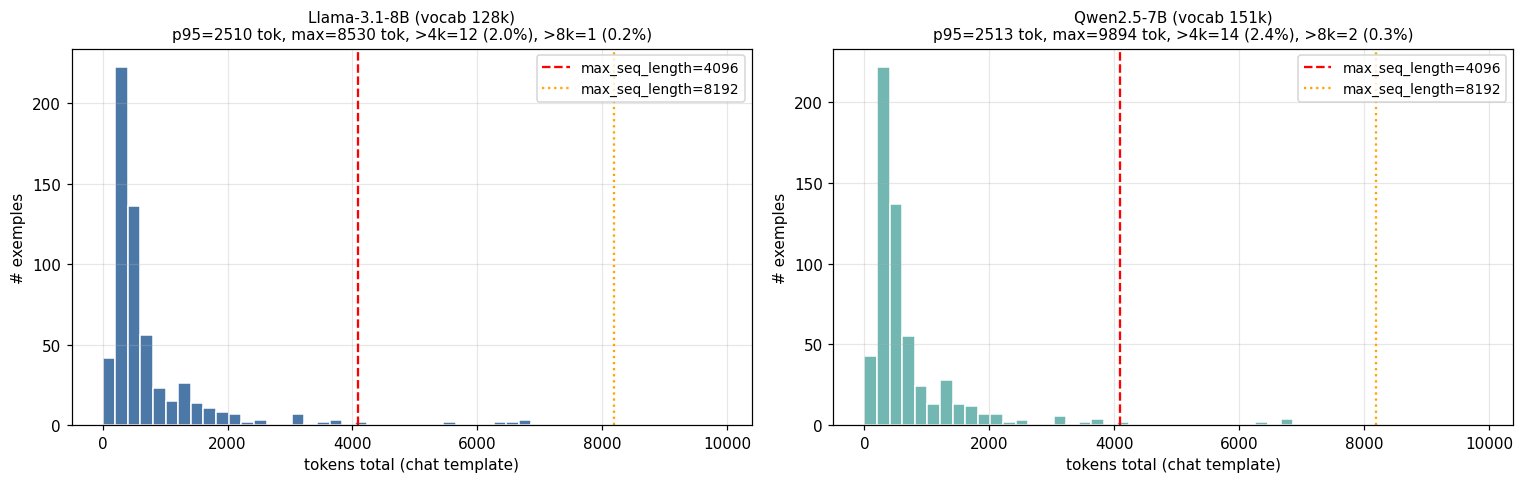

In [27]:
# 4.4 — Graphes : histogrammes tokens total Llama vs Qwen + barre verticale à 4096
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

XMAX = max(df['tok_llama_total'].max(), df['tok_qwen_total'].max())
BINS = np.linspace(0, XMAX, 50)

for ax, label, color, name in [
    (axes[0], 'llama', COLOR_PRIMARY,   'Llama-3.1-8B (vocab 128k)'),
    (axes[1], 'qwen',  COLOR_SECONDARY, 'Qwen2.5-7B (vocab 151k)'),
]:
    s = df[f'tok_{label}_total']
    ax.hist(s, bins=BINS, color=color, edgecolor='white')
    ax.axvline(4096, color='red', linestyle='--', linewidth=1.5, label='max_seq_length=4096')
    ax.axvline(8192, color='orange', linestyle=':',  linewidth=1.5, label='max_seq_length=8192')
    n_trunc_4k = (s > 4096).sum()
    n_trunc_8k = (s > 8192).sum()
    ax.set_title(f'{name}\np95={int(s.quantile(0.95))} tok, max={int(s.max())} tok, '
                 f'>4k={n_trunc_4k} ({100*n_trunc_4k/len(s):.1f}%), '
                 f'>8k={n_trunc_8k} ({100*n_trunc_8k/len(s):.1f}%)', fontsize=10)
    ax.set_xlabel('tokens total (chat template)')
    ax.set_ylabel('# exemples')
    ax.grid(alpha=0.3)
    ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig(FIGS_DIR / 'tokens_distribution.png')
plt.show()

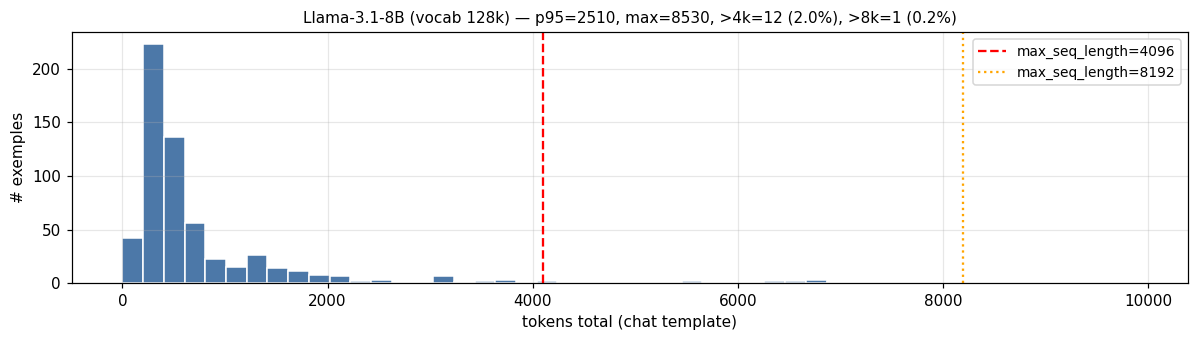

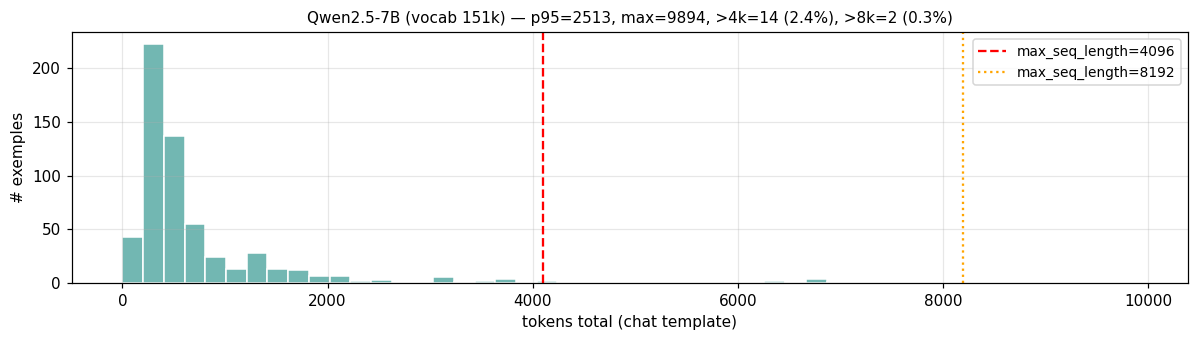

Saved: ['tokens_distribution_llama.png', 'tokens_distribution_qwen.png']


In [28]:
# 4.4bis — Tokens : aussi 2 PNG séparés (1 par tokenizer) pour layout vertical en slide
for label, color, name, fname in [
    ('llama', COLOR_PRIMARY,   'Llama-3.1-8B (vocab 128k)', 'tokens_distribution_llama.png'),
    ('qwen',  COLOR_SECONDARY, 'Qwen2.5-7B (vocab 151k)',   'tokens_distribution_qwen.png'),
]:
    s = df[f'tok_{label}_total']
    fig, ax = plt.subplots(figsize=(11, 3.2))
    ax.hist(s, bins=BINS, color=color, edgecolor='white')
    ax.axvline(4096, color='red', linestyle='--', linewidth=1.5, label='max_seq_length=4096')
    ax.axvline(8192, color='orange', linestyle=':', linewidth=1.5, label='max_seq_length=8192')
    n_trunc_4k = (s > 4096).sum()
    n_trunc_8k = (s > 8192).sum()
    ax.set_title(f'{name} — p95={int(s.quantile(0.95))}, max={int(s.max())}, '
                 f'>4k={n_trunc_4k} ({100*n_trunc_4k/len(s):.1f}%), '
                 f'>8k={n_trunc_8k} ({100*n_trunc_8k/len(s):.1f}%)', fontsize=10)
    ax.set_xlabel('tokens total (chat template)')
    ax.set_ylabel('# exemples')
    ax.grid(alpha=0.3)
    ax.legend(loc='upper right', fontsize=9)
    plt.tight_layout()
    plt.savefig(FIGS_DIR / fname)
    plt.show()
print('Saved:', sorted(f.name for f in FIGS_DIR.glob('tokens_distribution_*.png')))


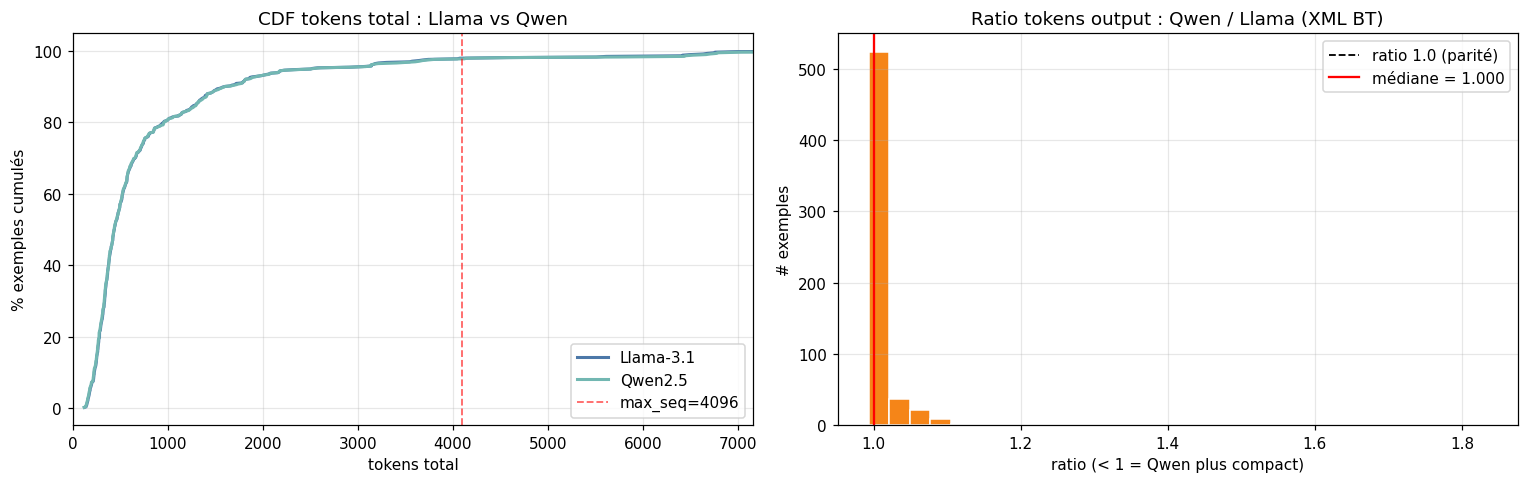

Ratio médian Qwen/Llama sur output XML : 1.000
  → Qwen compresse 0.0% plus dense que Llama sur XML BT


In [29]:
# 4.5 — Comparaison directe Llama vs Qwen sur même graphique (CDF) + ratio compression
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Subplot gauche : CDF des deux tokenizers
for label, color, name in [('llama', COLOR_PRIMARY,   'Llama-3.1'),
                            ('qwen',  COLOR_SECONDARY, 'Qwen2.5')]:
    s = df[f'tok_{label}_total'].sort_values()
    axes[0].plot(s.values, np.arange(1, len(s)+1) / len(s) * 100, label=name, color=color, linewidth=2)
axes[0].axvline(4096, color='red', linestyle='--', linewidth=1.2, alpha=0.6, label='max_seq=4096')
axes[0].set_title('CDF tokens total : Llama vs Qwen')
axes[0].set_xlabel('tokens total')
axes[0].set_ylabel('% exemples cumulés')
axes[0].set_xlim(0, df['tok_llama_total'].quantile(0.99) * 1.1)
axes[0].grid(alpha=0.3)
axes[0].legend()

# Subplot droite : ratio Qwen/Llama (compression Qwen vs Llama sur output XML)
ratio = df['tok_qwen_output'] / df['tok_llama_output']
axes[1].hist(ratio, bins=30, color=COLOR_ACCENT, edgecolor='white')
axes[1].axvline(1.0, color='black', linestyle='--', linewidth=1.2, label='ratio 1.0 (parité)')
axes[1].axvline(ratio.median(), color='red', linestyle='-', linewidth=1.5,
                label=f'médiane = {ratio.median():.3f}')
axes[1].set_title('Ratio tokens output : Qwen / Llama (XML BT)')
axes[1].set_xlabel('ratio (< 1 = Qwen plus compact)')
axes[1].set_ylabel('# exemples')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGS_DIR / 'tokens_comparison.png')
plt.show()

print(f'Ratio médian Qwen/Llama sur output XML : {ratio.median():.3f}')
print(f'  → Qwen compresse {(1-ratio.median())*100:.1f}% plus dense que Llama sur XML BT')

In [30]:
# 4.6 — Export CSV + Markdown rapport tokens
TOK_CSV = DATASET_DIR / 'tokens_distribution.csv'
trunc_table.to_csv(TOK_CSV, index=False)
print(f'CSV tokens exporté : {TOK_CSV}')

md = '## Analyse token count : Llama-3.1 vs Qwen2.5\n\n'
md += f'**Tokenizers utilisés :** `{llama_used}` et `{qwen_used}`\n\n'
md += '### Distribution tokens total (input + output + chat template)\n\n'
md += '| Tokenizer | mean | p50 | p90 | p95 | p99 | max | >2048 | >4096 | >8192 |\n'
md += '|---|---|---|---|---|---|---|---|---|---|\n'
for r in rows:
    md += (f'| {r["tokenizer"]} | {r["mean"]} | {r["p50"]} | {r["p90"]} | {r["p95"]} | '
           f'{r["p99"]} | {r["max"]} | {r["%>2048"]}% | {r["%>4096"]}% | {r["%>8192"]}% |\n')

md += f'\n### Ratio compression Qwen/Llama (output XML)\n\n'
md += f'**Médiane ratio :** {ratio.median():.3f} → Qwen produit en médiane '
md += f'{(1-ratio.median())*100:.1f}% moins de tokens que Llama pour le même XML.\n\n'

md += '### Décision pour le SFT\n\n'
n_trunc_llama_4k = (df["tok_llama_total"] > 4096).sum()
n_trunc_qwen_4k  = (df["tok_qwen_total"]  > 4096).sum()
md += f'- Avec `max_seq_length=4096` (config papier) : Llama tronque **{n_trunc_llama_4k} exemples** '
md += f'({100*n_trunc_llama_4k/len(df):.1f}%), Qwen **{n_trunc_qwen_4k}** '
md += f'({100*n_trunc_qwen_4k/len(df):.1f}%).\n'
md += '- Recommandation : conserver `max_seq_length=4096` pour fidélité au papier, documenter le taux '
md += 'de troncature dans le rapport. Si VRAM le permet en QLoRA sur RTX 3090, tester 8192 en ablation.\n'

TOK_MD = DATASET_DIR / 'tokens_report.md'
TOK_MD.write_text(md, encoding='utf-8')
print(f'Markdown tokens exporté : {TOK_MD}')

CSV tokens exporté : /home/bnj/WSL_RECUP/BTGenBot_Nav4Rails/dataset/tokens_distribution.csv
Markdown tokens exporté : /home/bnj/WSL_RECUP/BTGenBot_Nav4Rails/dataset/tokens_report.md


## Section 5 — Recovery patterns (profondeur 2 + 3)

**Objectif :** identifier les motifs structurels récurrents — surtout les patterns "Fallback/Sequence imbriqués" caractéristiques d'une logique de recovery.

**Méthode (reprise Anne §4 + élargissement profondeur 3) :** signature textuelle d'un sous-arbre via récursion — ex `Fallback(Sequence, Sequence)`. On compte la fréquence sur les 578 BTs valides, on garde le Top-20 à profondeur 2 puis 3.

**Pourquoi conserver les patterns :** ce sont les briques que le modèle apprendra naturellement. Documenter les patterns dominants justifie son comportement de génération en eval.

In [31]:
# 5.1 — Signature récursive d'un sous-arbre (adapté de Anne §4)
NOISE_FOR_PATTERNS = {'dummy_root', 'root', 'TreeNodesModel',
                      'input_port', 'output_port', 'inout_port'}

def get_signature(elem, depth=0, max_depth=2):
    """Sous-arbre → signature textuelle, ex 'Fallback(Sequence, Sequence)'."""
    if depth >= max_depth or len(list(elem)) == 0:
        return elem.tag
    children = [get_signature(c, depth + 1, max_depth)
                for c in elem if c.tag not in NOISE_FOR_PATTERNS]
    if not children:
        return elem.tag
    return f'{elem.tag}({", ".join(children)})'

# Sanity check
sample_root = df.loc[df['xml_valid_strict'], 'xml_root_strict'].iloc[0]
print('Signature exemple (depth=2) :', get_signature(sample_root, max_depth=2))
print('Signature exemple (depth=3) :', get_signature(sample_root, max_depth=3))

Signature exemple (depth=2) : root(BehaviorTree(PipelineSequence))
Signature exemple (depth=3) : root(BehaviorTree(PipelineSequence(RateController, FollowPath)))


In [32]:
# 5.2 — Extraction patterns : tous (depth 2 et 3) + ciblés Fallback/RecoveryNode
def extract_all_patterns(roots, max_depth):
    all_p = Counter()
    recovery_p = Counter()
    for root in roots:
        if root is None:
            continue
        for elem in root.iter():
            if elem.tag in NOISE_FOR_PATTERNS or elem.tag in BTCPP_STANDARD - {
                'Sequence','SequenceStar','ReactiveSequence','PipelineSequence','NonBlockingSequence',
                'Fallback','FallbackStar','ReactiveFallback','RecoveryNode',
            }:
                # On garde les nœuds de contrôle BT.CPP pour les patterns, on retire le reste de la STD
                continue
            sig = get_signature(elem, max_depth=max_depth)
            all_p[sig] += 1
            if elem.tag in {'Fallback','FallbackStar','ReactiveFallback','RecoveryNode'}:
                recovery_p[sig] += 1
    return all_p, recovery_p

roots_valid = df.loc[df['xml_valid_strict'], 'xml_root_strict'].tolist()

patterns_d2_all, patterns_d2_recovery = extract_all_patterns(roots_valid, max_depth=2)
patterns_d3_all, patterns_d3_recovery = extract_all_patterns(roots_valid, max_depth=3)

print(f'Patterns uniques (depth 2) : {len(patterns_d2_all)}')
print(f'Patterns uniques (depth 3) : {len(patterns_d3_all)}')
print(f'Patterns Fallback uniques (depth 2) : {len(patterns_d2_recovery)}')
print(f'Patterns Fallback uniques (depth 3) : {len(patterns_d3_recovery)}')

Patterns uniques (depth 2) : 1564
Patterns uniques (depth 3) : 1651
Patterns Fallback uniques (depth 2) : 338
Patterns Fallback uniques (depth 3) : 363


In [33]:
# 5.3 — Tables Top-20 patterns (tous + recovery uniquement)
TOP_K = 20

def to_top_df(counter, k):
    return pd.DataFrame(counter.most_common(k), columns=['pattern', 'count'])

top_d2_all      = to_top_df(patterns_d2_all,      TOP_K)
top_d3_all      = to_top_df(patterns_d3_all,      TOP_K)
top_d2_recovery = to_top_df(patterns_d2_recovery, TOP_K)
top_d3_recovery = to_top_df(patterns_d3_recovery, TOP_K)

print(f'=== Top {TOP_K} patterns Fallback/RecoveryNode (depth 2) ===')
print(top_d2_recovery.to_string(index=False))
print(f'\n=== Top {TOP_K} patterns Fallback/RecoveryNode (depth 3) ===')
print(top_d3_recovery.to_string(index=False))

=== Top 20 patterns Fallback/RecoveryNode (depth 2) ===
                                                                                                  pattern  count
                                                                              Fallback(Condition, Action)     31
                                                                Fallback(Condition, ForceFailure(Action))     27
                                                             RecoveryNode(FollowPath, ClearEntireCostmap)     26
                                                                                 Fallback(Action, Action)     25
                                                                   Fallback(Action, ForceFailure(Action))     25
RecoveryNode(PipelineSequence(RateController, RecoveryNode), ReactiveFallback(GoalUpdated, SequenceStar))     23
                                                      RecoveryNode(ComputePathToPose, ClearEntireCostmap)     21
          ReactiveFallback(GoalUpdated, 

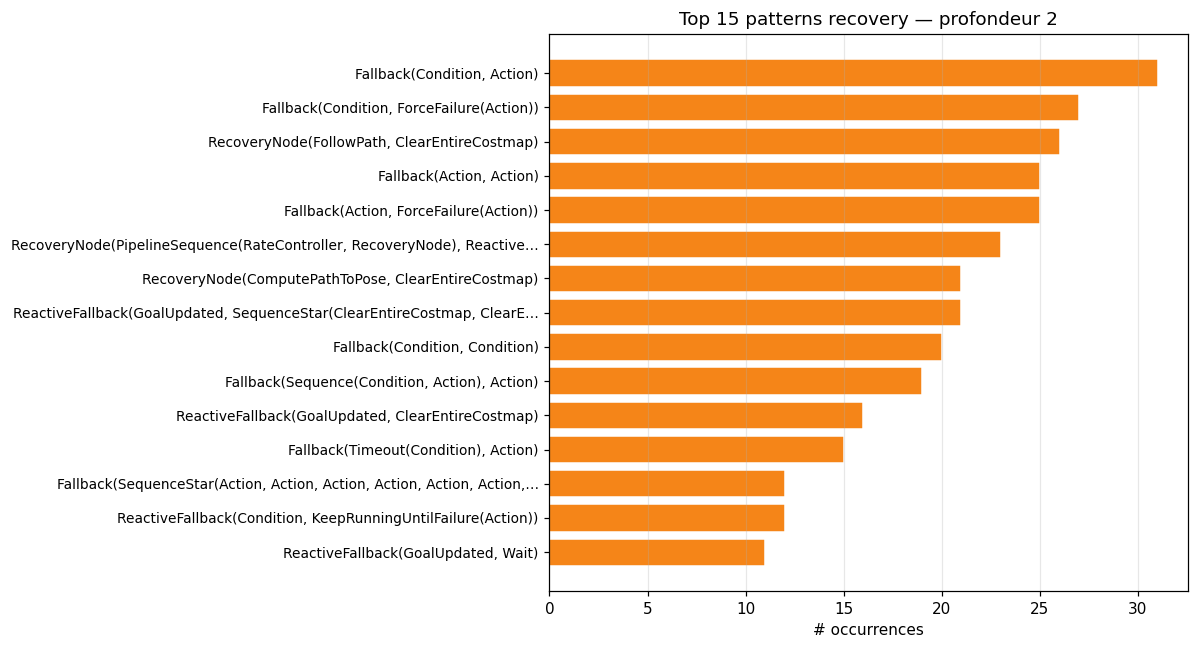

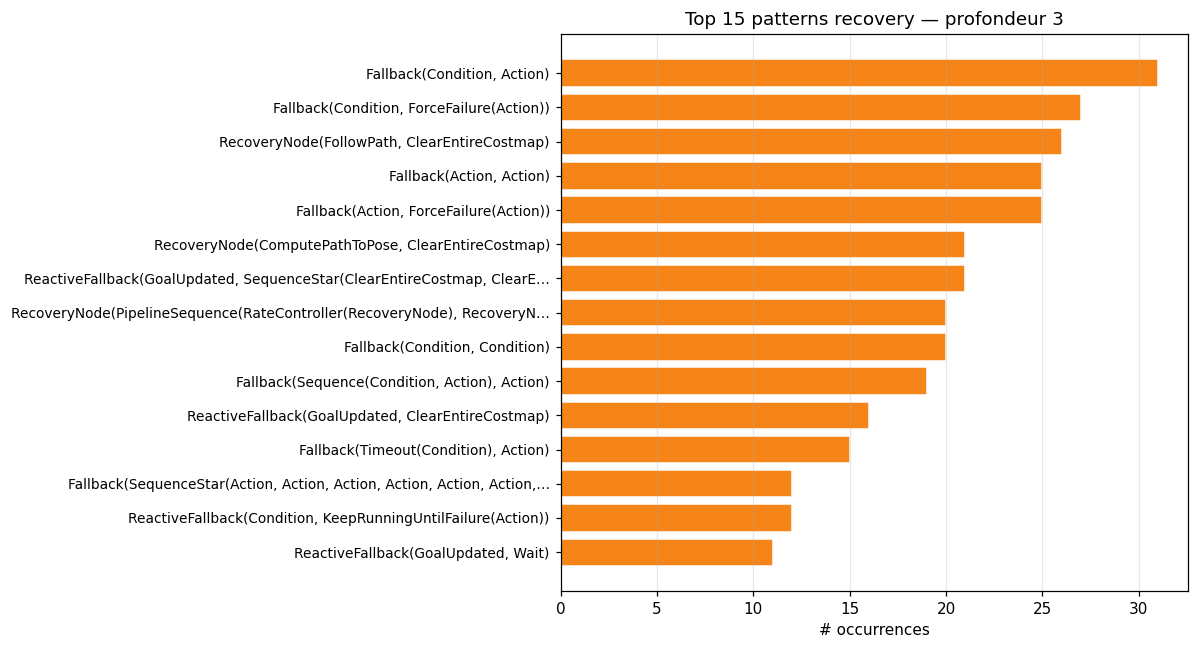

In [34]:
# 5.4 — Graphes : Top-15 patterns recovery (2 figures séparées pour éviter overlap labels longs)
MAX_LABEL_LEN = 70

def truncate(s, n=MAX_LABEL_LEN):
    return s if len(s) <= n else s[:n-1] + '…'

for top_df, depth, fname in [
    (top_d2_recovery.head(15).iloc[::-1], 2, 'recovery_patterns_d2.png'),
    (top_d3_recovery.head(15).iloc[::-1], 3, 'recovery_patterns_d3.png'),
]:
    fig, ax = plt.subplots(figsize=(11, 6))
    labels = [truncate(p) for p in top_df['pattern']]
    ax.barh(labels, top_df['count'], color=COLOR_ACCENT, edgecolor='white')
    ax.set_title(f'Top 15 patterns recovery — profondeur {depth}')
    ax.set_xlabel('# occurrences')
    ax.tick_params(axis='y', labelsize=9)
    ax.grid(alpha=0.3, axis='x')
    plt.tight_layout()
    plt.savefig(FIGS_DIR / fname)
    plt.show()


In [35]:
# 5.5 — Export CSV + Markdown rapport patterns
PAT_CSV = DATASET_DIR / 'recovery_patterns.csv'
combined = pd.concat([
    top_d2_recovery.assign(scope='recovery', depth=2),
    top_d3_recovery.assign(scope='recovery', depth=3),
    top_d2_all.assign(scope='all', depth=2),
    top_d3_all.assign(scope='all', depth=3),
], ignore_index=True)
combined.to_csv(PAT_CSV, index=False)
print(f'CSV patterns exporté : {PAT_CSV}')

md = '## Recovery patterns dans le dataset BTGenBot\n\n'
md += f'**Méthode :** signature récursive d\'un sous-arbre, type `Fallback(Sequence, Sequence)`. '
md += f'Extraction sur {len(roots_valid)} BTs valides (parse strict).\n\n'
md += '### Top 10 patterns Fallback/RecoveryNode (profondeur 2)\n\n| Pattern | Count |\n|---|---|\n'
for _, r in top_d2_recovery.head(10).iterrows():
    md += f'| `{r["pattern"]}` | {r["count"]} |\n'
md += '\n### Top 10 patterns Fallback/RecoveryNode (profondeur 3)\n\n| Pattern | Count |\n|---|---|\n'
for _, r in top_d3_recovery.head(10).iterrows():
    md += f'| `{r["pattern"]}` | {r["count"]} |\n'
md += '\n### Lecture\n\n'
md += '- Le pattern dominant à profondeur 2 est `Fallback(Sequence, Sequence)` — motif "try then recover".\n'
md += '- À profondeur 3 on voit apparaître les variantes imbriquées (`Fallback(Sequence(Fallback))`, etc.) '
md += 'qui sont la signature de la stratégie de recovery cascadée standard Nav2.\n'
md += '- Implication pour le SFT : le modèle apprendra ces motifs récurrents en priorité, '
md += 'utile pour les tâches d\'inspection SNCF qui nécessiteront aussi un comportement "essayer puis se rabattre" '
md += '(ex : capture image → réessayer depuis autre angle → renoncer).\n'

PAT_MD = DATASET_DIR / 'recovery_patterns_report.md'
PAT_MD.write_text(md, encoding='utf-8')
print(f'Markdown patterns exporté : {PAT_MD}')

CSV patterns exporté : /home/bnj/WSL_RECUP/BTGenBot_Nav4Rails/dataset/recovery_patterns.csv
Markdown patterns exporté : /home/bnj/WSL_RECUP/BTGenBot_Nav4Rails/dataset/recovery_patterns_report.md


## Section 6 — Smoke test set

**Objectif :** isoler ~15 BTs représentatifs comme **set de test rapide manuel** après le SFT. Permet de regarder à l'œil ce que le modèle génère sur des cas variés (catégorie × taille) sans devoir lancer une eval complète.

**Pas un test set scientifique** — c'est un harnais d'inspection humaine. La métrique de validation finale reste les 9 tâches du papier BTGenBot.

**Stratification cible (15 BTs) :**
- **navigation** : 3 small + 3 medium + 3 large = 9
- **manipulation** : 1 small + 1 medium = 2
- **perception** : 1 small + 1 medium = 2
- **other** : 1 small + 1 medium = 2

**Buckets de taille** (basés sur `bt_node_count`) :
- `small` : ≤ 10 nœuds
- `medium` : 11–40 nœuds
- `large` : > 40 nœuds

**Seed fixé = 42** pour reproductibilité.

**Décision :** ces 15 BTs sont **flaggés mais pas retirés** du dataset d'entraînement — on garde les 594 pour fidélité papier. Le smoke test sert uniquement de référence visuelle.


In [36]:
# 6.1 — Bucket de taille basé sur bt_node_count
def size_bucket(n):
    if pd.isna(n):
        return 'unknown'
    if n <= 10:
        return 'small'
    if n <= 40:
        return 'medium'
    return 'large'

df['size_bucket'] = df['bt_node_count'].apply(size_bucket)
print('Distribution catégorie × bucket :')
ct = pd.crosstab(df['category'], df['size_bucket'])
print(ct)


Distribution catégorie × bucket :
size_bucket   large  medium  small  unknown
category                                   
exploration       0       2      0        0
manipulation     10      16     15        2
navigation       89     203    133        9
other             5      35     55        5
perception        1       9      5        0


In [37]:
# 6.2 — Sélection stratifiée 15 BTs
SMOKE_SPEC = [
    ('navigation',   'small',  3),
    ('navigation',   'medium', 3),
    ('navigation',   'large',  3),
    ('manipulation', 'small',  1),
    ('manipulation', 'medium', 1),
    ('perception',   'small',  1),
    ('perception',   'medium', 1),
    ('other',        'small',  1),
    ('other',        'medium', 1),
]

SEED = 42
smoke_ids = []
for cat, bucket, n in SMOKE_SPEC:
    pool = df[(df['category'] == cat)
              & (df['size_bucket'] == bucket)
              & (df['xml_valid_strict'])]['record_id']
    actual_n = min(n, len(pool))
    if actual_n == 0:
        print(f'  [skip] {cat}/{bucket} : pool vide')
        continue
    chosen = pool.sample(n=actual_n, random_state=SEED).tolist()
    smoke_ids.extend(chosen)
    print(f'  [{cat}/{bucket}] {actual_n}/{n} sélectionnés : {chosen}')

print(f'\nTotal smoke test : {len(smoke_ids)} BTs')

df['in_smoke_test'] = df['record_id'].isin(smoke_ids)


  [navigation/small] 3/3 sélectionnés : [223, 303, 133]
  [navigation/medium] 3/3 sélectionnés : [50, 36, 357]
  [navigation/large] 3/3 sélectionnés : [363, 405, 241]
  [manipulation/small] 1/1 sélectionnés : [453]
  [manipulation/medium] 1/1 sélectionnés : [8]
  [perception/small] 1/1 sélectionnés : [78]
  [perception/medium] 1/1 sélectionnés : [507]
  [other/small] 1/1 sélectionnés : [214]
  [other/medium] 1/1 sélectionnés : [359]

Total smoke test : 15 BTs


In [38]:
# 6.3 — Récap smoke test + export
smoke_df = df[df['in_smoke_test']][[
    'record_id', 'category', 'size_bucket', 'bt_node_count', 'bt_max_depth',
    'has_recovery_pattern', 'tok_llama_total', 'tok_qwen_total'
]].sort_values(['category', 'size_bucket', 'record_id']).reset_index(drop=True)
print(smoke_df.to_string(index=False))


 record_id     category size_bucket  bt_node_count  bt_max_depth  has_recovery_pattern  tok_llama_total  tok_qwen_total
         8 manipulation      medium           23.0           6.0                 False              536             531
       453 manipulation       small            7.0           3.0                 False              200             195
       241   navigation       large          117.0           7.0                  True             1417            1413
       363   navigation       large          288.0           8.0                  True             3143            3139
       405   navigation       large           67.0           5.0                  True             1311            1306
        36   navigation      medium           13.0           6.0                  True              959             954
        50   navigation      medium           12.0           4.0                  True              365             364
       357   navigation      medium     

In [39]:
# 6.4 — Export smoke test set (indices + JSON détaillé)
SMOKE_IDX_PATH = SPLITS_DIR / 'smoke_test_idx.json'
SMOKE_DETAIL_PATH = SPLITS_DIR / 'smoke_test_detail.json'

# Indices simples
SMOKE_IDX_PATH.write_text(json.dumps({
    'smoke_test_record_ids': sorted(smoke_ids),
    'n': len(smoke_ids),
    'seed': SEED,
    'spec': [[cat, bucket, n] for cat, bucket, n in SMOKE_SPEC],
}, indent=2))
print(f'Indices exportés : {SMOKE_IDX_PATH}')

# Détail complet (input + output + métadonnées)
detail_records = []
for _, r in smoke_df.iterrows():
    rid = int(r['record_id'])
    src = df[df['record_id'] == rid].iloc[0]
    detail_records.append({
        'record_id': rid,
        'category': r['category'],
        'size_bucket': r['size_bucket'],
        'bt_node_count': int(r['bt_node_count']),
        'bt_max_depth': int(r['bt_max_depth']),
        'has_recovery_pattern': bool(r['has_recovery_pattern']),
        'tok_llama_total': int(r['tok_llama_total']),
        'tok_qwen_total': int(r['tok_qwen_total']),
        'input': src['input'],
        'output': src['output'],
    })
SMOKE_DETAIL_PATH.write_text(json.dumps(detail_records, indent=2, ensure_ascii=False))
print(f'Détail exporté : {SMOKE_DETAIL_PATH}')

# Markdown rapport
md = '## Smoke test set (15 BTs)\n\n'
md += f'**Seed :** {SEED} — **n :** {len(smoke_ids)} BTs (fidèles aux 594 originaux, non retirés du train).\n\n'
md += '### Composition\n\n| Catégorie | Bucket | n | record_ids |\n|---|---|---|---|\n'
for (cat, bucket), grp in smoke_df.groupby(['category', 'size_bucket']):
    ids = ', '.join(str(i) for i in grp['record_id'].tolist())
    md += f'| {cat} | {bucket} | {len(grp)} | {ids} |\n'
md += '\n**Usage :** après chaque SFT, générer les sorties du modèle sur ces 15 inputs et comparer à la main aux outputs de référence. Permet repérer rapidement les modes de défaillance (XML cassé, structure plate, oubli recovery, etc.) sans lancer l\'eval complète.\n'
(DATASET_DIR / 'smoke_test_report.md').write_text(md, encoding='utf-8')
print(f'Markdown smoke test exporté : {DATASET_DIR / "smoke_test_report.md"}')


Indices exportés : /home/bnj/WSL_RECUP/BTGenBot_Nav4Rails/dataset/splits/smoke_test_idx.json
Détail exporté : /home/bnj/WSL_RECUP/BTGenBot_Nav4Rails/dataset/splits/smoke_test_detail.json
Markdown smoke test exporté : /home/bnj/WSL_RECUP/BTGenBot_Nav4Rails/dataset/smoke_test_report.md


## Section 7 — JSONL trainable

**Objectif :** produire le dataset prêt pour le SFT (594 exemples, fidélité papier). Deux formats exportés :
- **Chat** (`btgenbot_chat.jsonl`) : format primaire pour Llama-3.1-Instruct et Qwen2.5-Instruct (rôles `system`/`user`/`assistant`)
- **Alpaca** (`btgenbot_alpaca.jsonl`) : format secondaire (instruction/input/output), utile si on fine-tune un base model non-instruct

**Métadonnées embarquées dans chaque ligne :** `record_id`, `category`, `has_recovery_pattern`, `in_smoke_test`, `tok_llama_total`, `tok_qwen_total`, `xml_valid_strict`. Le SFTTrainer ignore ces champs (lit juste `messages` ou `instruction/input/output`), mais ils permettent du filtrage/analyse downstream sans réjoindre les CSV.

**System prompt = v1 (fidélité papier) :** repris tel quel de l'instruction Alpaca originale du dataset.

**Note :** pas de split train/val/test. Le papier utilise tout le dataset pour SFT et évalue sur les 9 tâches custom. On suit.


In [40]:
# 7.1 — Construction des records JSONL (chat + alpaca) avec métadonnées
META_COLS = [
    'record_id', 'category', 'has_recovery_pattern', 'in_smoke_test',
    'xml_valid_strict', 'bt_node_count', 'bt_max_depth',
    'tok_llama_total', 'tok_qwen_total',
]

def to_metadata(row):
    out = {}
    for col in META_COLS:
        v = row[col]
        if pd.isna(v):
            out[col] = None
        elif isinstance(v, (bool, np.bool_)):
            out[col] = bool(v)
        elif isinstance(v, (int, np.integer)):
            out[col] = int(v)
        elif isinstance(v, (float, np.floating)):
            out[col] = float(v)
        else:
            out[col] = v
    return out

chat_records = []
alpaca_records = []

for _, row in df.iterrows():
    meta = to_metadata(row)
    user_text = str(row['input'])
    assistant_text = str(row['output'])
    
    # Format chat
    chat_records.append({
        'messages': [
            {'role': 'system',    'content': SYSTEM_MSG},
            {'role': 'user',      'content': user_text},
            {'role': 'assistant', 'content': assistant_text},
        ],
        'metadata': meta,
    })
    
    # Format Alpaca
    alpaca_records.append({
        'instruction': str(row['instruction']),
        'input':       user_text,
        'output':      assistant_text,
        'metadata':    meta,
    })

print(f'Chat records   : {len(chat_records)}')
print(f'Alpaca records : {len(alpaca_records)}')
print(f'\nExemple chat (record_id={chat_records[0]["metadata"]["record_id"]}):')
print(f'  system  : {chat_records[0]["messages"][0]["content"][:80]}...')
print(f'  user    : {chat_records[0]["messages"][1]["content"][:80]}...')
print(f'  asst    : {chat_records[0]["messages"][2]["content"][:80]}...')
print(f'  metadata: {chat_records[0]["metadata"]}')


Chat records   : 594
Alpaca records : 594

Exemple chat (record_id=0):
  system  : You will be provided a summary of a task performed by a behavior tree, and your ...
  user    : The behavior tree orchestrates the navigation of a robot by periodically replann...
  asst    : <!--
  This Behavior Tree replans the global path periodically at 1 Hz.
-->

<ro...
  metadata: {'record_id': 0, 'category': 'navigation', 'has_recovery_pattern': False, 'in_smoke_test': False, 'xml_valid_strict': True, 'bt_node_count': 6.0, 'bt_max_depth': 4.0, 'tok_llama_total': 254, 'tok_qwen_total': 249}


In [41]:
# 7.2 — Export JSONL chat + Alpaca
CHAT_PATH   = DATASET_DIR / 'btgenbot_chat.jsonl'
ALPACA_PATH = DATASET_DIR / 'btgenbot_alpaca.jsonl'

def write_jsonl(records, path):
    with path.open('w', encoding='utf-8') as f:
        for r in records:
            f.write(json.dumps(r, ensure_ascii=False) + '\n')

write_jsonl(chat_records,   CHAT_PATH)
write_jsonl(alpaca_records, ALPACA_PATH)

print(f'Chat   : {CHAT_PATH} ({CHAT_PATH.stat().st_size // 1024} KB)')
print(f'Alpaca : {ALPACA_PATH} ({ALPACA_PATH.stat().st_size // 1024} KB)')


Chat   : /home/bnj/WSL_RECUP/BTGenBot_Nav4Rails/dataset/btgenbot_chat.jsonl (2360 KB)
Alpaca : /home/bnj/WSL_RECUP/BTGenBot_Nav4Rails/dataset/btgenbot_alpaca.jsonl (2317 KB)


In [42]:
# 7.3 — Validation : reload + sanity check
def read_jsonl(path):
    with path.open('r', encoding='utf-8') as f:
        return [json.loads(line) for line in f]

chat_reload   = read_jsonl(CHAT_PATH)
alpaca_reload = read_jsonl(ALPACA_PATH)

assert len(chat_reload) == 594,   f'Expected 594 chat, got {len(chat_reload)}'
assert len(alpaca_reload) == 594, f'Expected 594 alpaca, got {len(alpaca_reload)}'

# Vérifier que chaque ligne chat a 3 messages dans le bon ordre
for i, r in enumerate(chat_reload):
    msgs = r['messages']
    assert len(msgs) == 3, f'record {i}: {len(msgs)} messages au lieu de 3'
    assert msgs[0]['role'] == 'system'
    assert msgs[1]['role'] == 'user'
    assert msgs[2]['role'] == 'assistant'

# Vérifier métadonnées
assert all('metadata' in r and 'record_id' in r['metadata'] for r in chat_reload)
ids_in_jsonl = sorted(r['metadata']['record_id'] for r in chat_reload)
assert ids_in_jsonl == list(range(594)), 'record_ids manquants ou dupliqués'

n_smoke = sum(1 for r in chat_reload if r['metadata']['in_smoke_test'])
n_invalid = sum(1 for r in chat_reload if not r['metadata']['xml_valid_strict'])
print(f'[ok] 594 lignes chat + 594 alpaca, structure conforme')
print(f'[ok] {n_smoke} lignes flaggées smoke_test, {n_invalid} lignes XML invalides (gardées, fidélité papier)')


[ok] 594 lignes chat + 594 alpaca, structure conforme
[ok] 15 lignes flaggées smoke_test, 16 lignes XML invalides (gardées, fidélité papier)


In [43]:
# 7.4 — Vérification chat_template : produire la string finale d\'un exemple pour Llama et Qwen
sample = chat_records[0]
print('===== Llama-3.1 apply_chat_template (preview 400 chars) =====')
formatted_llama = tok_llama.apply_chat_template(sample['messages'], tokenize=False, add_generation_prompt=False)
print(formatted_llama[:400])
print('...')
print('\n===== Qwen2.5 apply_chat_template (preview 400 chars) =====')
formatted_qwen = tok_qwen.apply_chat_template(sample['messages'], tokenize=False, add_generation_prompt=False)
print(formatted_qwen[:400])
print('...')


===== Llama-3.1 apply_chat_template (preview 400 chars) =====
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

You will be provided a summary of a task performed by a behavior tree, and your objective is to express this behavior tree in XML format.<|eot_id|><|start_header_id|>user<|end_header_id|>

The behavior tree orchestrates the navigation of a robot by periodically replanning its global path at a frequency of 1 Hz. It utilizes a pipeline seq
...

===== Qwen2.5 apply_chat_template (preview 400 chars) =====
<|im_start|>system
You will be provided a summary of a task performed by a behavior tree, and your objective is to express this behavior tree in XML format.<|im_end|>
<|im_start|>user
The behavior tree orchestrates the navigation of a robot by periodically replanning its global path at a frequency of 1 Hz. It utilizes a pipeline sequence, where it first computes a path to a specified goal using a 
...


In [44]:
# 7.5 — Markdown rapport final
REPORT_TEMPLATE = """## Export JSONL trainable

**Dataset :** 594 exemples (fidélité papier BTGenBot, aucun filtrage appliqué).

### Fichiers générés

| Fichier | Format | Lignes | Taille |
|---|---|---|---|
| `dataset/btgenbot_chat.jsonl` | chat (messages) | {n_chat} | {chat_kb} KB |
| `dataset/btgenbot_alpaca.jsonl` | alpaca | {n_alpaca} | {alpaca_kb} KB |

### Format chat (utilisé pour SFT)

```json
{{"messages": [
  {{"role": "system",    "content": "..."}},
  {{"role": "user",      "content": "..."}},
  {{"role": "assistant", "content": "..."}}
], "metadata": {{...}}}}
```

### System prompt (v1 papier)

```
{system_msg}
```

### Métadonnées embarquées

`{meta_cols}`

Le SFTTrainer ignore ces champs (lit juste `messages` ou `instruction/input/output`),
mais ils permettent du filtrage et de l'analyse downstream sans réjoindre les CSV.

### Usage SFT (exemple TRL)

```python
from datasets import load_dataset
ds = load_dataset("json", data_files="btgenbot_chat.jsonl", split="train")
# SFTTrainer lira le champ messages et appliquera le chat_template du tokenizer
```
"""

md = REPORT_TEMPLATE.format(
    n_chat=len(chat_records),
    n_alpaca=len(alpaca_records),
    chat_kb=CHAT_PATH.stat().st_size // 1024,
    alpaca_kb=ALPACA_PATH.stat().st_size // 1024,
    system_msg=SYSTEM_MSG,
    meta_cols=", ".join(META_COLS),
)

REPORT_PATH = DATASET_DIR / "jsonl_export_report.md"
REPORT_PATH.write_text(md, encoding="utf-8")
print(f"Markdown rapport exporté : {REPORT_PATH}")


Markdown rapport exporté : /home/bnj/WSL_RECUP/BTGenBot_Nav4Rails/dataset/jsonl_export_report.md


## Section 8 — Versioning des prompts

**Objectif :** centraliser les prompts (system + instruction) dans `dataset/prompts.json` pour traçabilité. Permet d'ajouter facilement des variantes (v2 enrichi BT.CPP, v3 SNCF, etc.) sans toucher au code.

**v1 (papier) :** repris tel quel de l'instruction Alpaca du dataset BTGenBot. C'est la version utilisée dans le JSONL exporté Section 7.

**v2 (enrichi BT.CPP)** : variante avec rappel structurel explicite (Sequence/Fallback/Action/Condition + syntaxe blackboard `{var}`). À tester en ablation semaine 3 si temps disponible.

**Choix par défaut pour SFT semaine 2 :** **v1**, fidélité papier.


In [45]:
# 8.1 — Versionner les prompts dans dataset/prompts.json
PROMPTS = {
    "v1_paper": {
        "version": "v1_paper",
        "description": "Prompt original du papier BTGenBot (Izzo 2024). Instruction Alpaca du dataset.",
        "system": (
            "You will be provided a summary of a task performed by a behavior tree, "
            "and your objective is to express this behavior tree in XML format."
        ),
        "used_in_sft": True,
    },
    "v2_btcpp_enriched": {
        "version": "v2_btcpp_enriched",
        "description": "Variante enrichie : rappel BehaviorTree.CPP v4 (structure root/BehaviorTree, nœuds standards, blackboard).",
        "system": (
            "You will be provided a summary of a task performed by a behavior tree, "
            "and your objective is to express this behavior tree in XML format. "
            "Generate a valid BehaviorTree.CPP v4 XML tree wrapped in <root> with a single "
            "<BehaviorTree> named MainTree. Use Sequence/Fallback/Action/Condition nodes. "
            "Blackboard variables use {var} syntax."
        ),
        "used_in_sft": False,
    },
}

PROMPTS_PATH = DATASET_DIR / "prompts.json"
PROMPTS_PATH.write_text(json.dumps(PROMPTS, indent=2, ensure_ascii=False), encoding="utf-8")

# Sanity check : la v1 ici doit matcher le SYSTEM_MSG utilisé Section 4 et Section 7
assert PROMPTS["v1_paper"]["system"] == SYSTEM_MSG, (
    "Mismatch v1_paper vs SYSTEM_MSG : risque d'incohérence entre JSONL exporté et prompts.json"
)
print(f"Prompts exportés : {PROMPTS_PATH}")
print(f"  v1_paper          : utilisée pour SFT semaine 2 (fidélité papier)")
print(f"  v2_btcpp_enriched : disponible pour ablation semaine 3")
print(f"\n[ok] v1_paper concorde avec SYSTEM_MSG utilisé pour le JSONL.")


Prompts exportés : /home/bnj/WSL_RECUP/BTGenBot_Nav4Rails/dataset/prompts.json
  v1_paper          : utilisée pour SFT semaine 2 (fidélité papier)
  v2_btcpp_enriched : disponible pour ablation semaine 3

[ok] v1_paper concorde avec SYSTEM_MSG utilisé pour le JSONL.
